# Очистка данных

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/reviews.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [20]:
df.isna().sum()

,0
review,0
sentiment,0


Видим, что пропусков нет

In [21]:
df['review'].value_counts()

,count
review,
"Loved today's show!!! It was a variety and not solely cooking (which would have been great too). Very stimulating and captivating, always keeping the viewer peeking around the corner to see what was coming up next. She is as down to earth and as personable as you get, like one of us which made the show all the more enjoyable. Special guests, who are friends as well made for a nice surprise too. Loved the 'first' theme and that the audience was invited to play along too. I must admit I was shocked to see her come in under her time limits on a few things, but she did it and by golly I'll be writing those recipes down. Saving time in the kitchen means more time with family. Those who haven't tuned in yet, find out what channel and the time, I assure you that you won't be disappointed.",5
"Hilarious, clean, light-hearted, and quote-worthy. What else can you ask for in a film? This is my all-time, number one favorite movie. Ever since I was a little girl, I've dreamed of owning a blue van with flames and an observation bubble.<br /><br />The cliché characters in ridiculous situations are what make this film such great fun. The wonderful comedic chemistry between Stephen Furst (Harold) and Andy Tennant (Melio) make up most of my favorite parts of the movie. And who didn't love the hopeless awkwardness of Flynch? Don't forget the airport antics of Leon's cronies, dressed up as Hari Krishnas: dancing, chanting and playing the tambourine--unbeatable! The clues are genius, the locations are classic, and the plot is timeless.<br /><br />A word to the wise, if you didn't watch this film when you were little, it probably won't win a place in your heart today. But nevertheless give it a chance, you may find that ""It doesn't matter what you say, it doesn't matter what you do, you've gotta play.""",4
"You do realize that you've been watching the EXACT SAME SHOW for eight years, right? I could understand the initial curiosity of seeing strangers co-exist on an Island, but you'd think that after watching unkempt, stink-ladened heroes run roughshod through the bush with an egg on a spoon for half a decade would be enough to get you to commit to something a little more original (and interesting).<br /><br />And I'm not even speaking of the shows validity which for the record I find questionable. It's just hard to suspend disbelief for ""Bushy Bill"" eating a rat when the entire crew of producers and camera people are housed in an air conditioned make-shift bio-dome sipping frosty mochcinno's with moxy.<br /><br />What's the appeal here? I don't care about these people or their meandering lives. I just don't get it. But if you DO find yourself being captivated by hairy, unwashed people, I suggest you turn off your TV and just take a trip to your local bus station where you can see people like this in their TRUE habitat. They call them HOMELESS PEOPLE, and free of charge, you can sit back and marvel in their uncanny ability to retrieve various cigarette debris from a plethora of garbage canisters, eventually striking ""pay-dirt"" and fashioning a homemade Dr. Frankenstein-styled cancer-stick, all the while begging people for change for food when the stink of ""Aqua Velva"" on their breath is enough to suggest otherwise. And the best part? Much like Survivor, every week one member of the tribe ""Leaves"" the ""Island"" when they are unceremoniously sent packing to the local Institution when the frightening unmedicated state of full-blown schizophrenia kicks into gear! Now THAT'S ENTERTAINMENT!",3
"I see that C. Thomas Howell has appeared in many movies since his heyday in the 80s as an accomplished young actor.<br /><br />I bought this DVD because it was cheap and in part for the internet-related plot and to see how much older C. Thomas Howell is; I do not recall seeing him in any movies since the 1980s.<br /><br />In just a few words: what a very big disappointment. I give some low budget movies a chance, but this one started out l

Видим, что некоторые отзывы повторяются. Видимо, кому-то было лень писать от себя что-то, поэтому просто копировал отзывы других зрителей

In [22]:
df['review'].nunique()

49582

Всего уникальных отзывов 49582. Т.е. 418 отзывов являются дубликатами. Они не несут никакой полезной информации для нас -> можно удалить

Но давайте ради интереса посмотрим: имеют ли дубликаты отзывов такую же оценку - позитив или негатив

In [38]:
duplicated_reviews = df[df['review'].duplicated(keep=False)]

(duplicated_reviews.groupby('review').nunique(dropna=False) > 1).any(axis=1).any()

np.False_

Видим, что одинаковые все одинаковые отзывы имеют одинаковую оценку со своими дубликатами. Значит можем смело удалить всех клонов

In [39]:
df = df.drop_duplicates()

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49582 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     49582 non-null  object
 1   sentiment  49582 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


# EDA

Посмотрии визуализацию балансов позитивных и негативных отзхывов

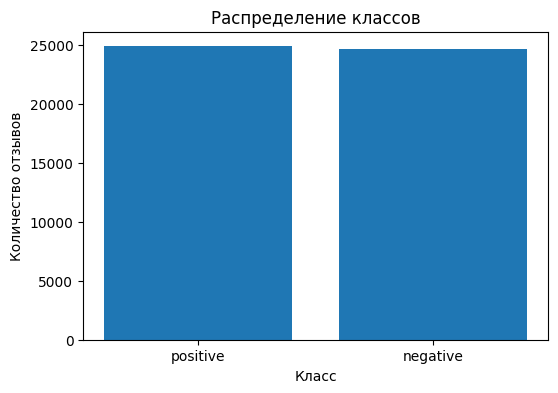

In [47]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество отзывов')

plt.show()

Видим, что кол-во позитивных и негативных отзывов примерно одинаковое, около 2450

## Исследование длины отзывов

In [48]:
df['review_length'] = df['review'].str.len()

df['review_length'].describe()

/tmp/ipykernel_4022/2307438270.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_length'] = df['review'].str.len()


,review_length
count,49582.000000
mean,1310.568230
std,990.762238
min,32.000000
25%,699.000000
50%,971.000000
75%,1592.000000
max,13704.000000


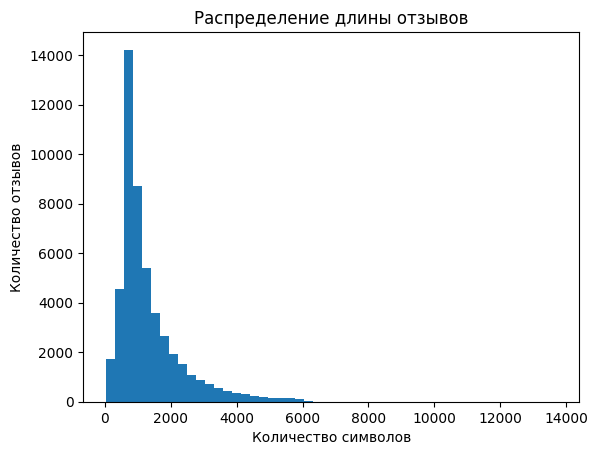

In [49]:
plt.hist(df['review_length'], bins=50)

plt.title('Распределение длины отзывов')
plt.xlabel('Количество символов')
plt.ylabel('Количество отзывов')

plt.show()

Видно, что распределение имеет выраженную правую асимметрию: большинство отзывов имеют длину примерно от 500 до 2000 символов, однако присутствует небольшое количество очень длинных отзывов длиной более 5000 символов. Из-за таких длинных текстов распределение имеет длинный правый хвост.

Посмотрим длину отзывов по классам

In [50]:
df.groupby('sentiment')['review_length'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,24698.0,1294.739615,946.501793,32.0,706.0,974.0,1568.00,8969.0
positive,24884.0,1326.278532,1032.597204,65.0,692.0,969.0,1615.25,13704.0


И посмотрим боксплоты, чтобы увидеть наглядно выбросы

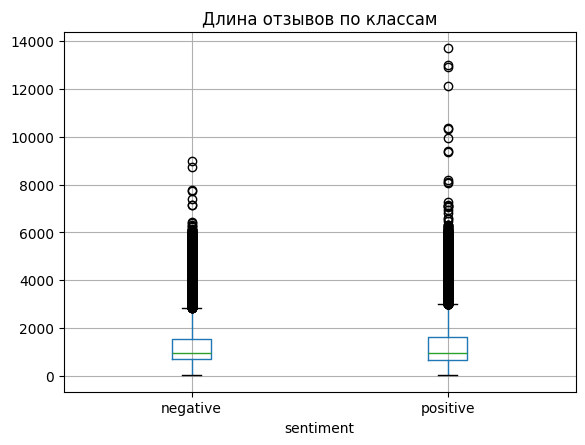

In [51]:
df.boxplot(column='review_length', by='sentiment')

plt.title('Длина отзывов по классам')
plt.suptitle('')
plt.show()

- медиана длины отзывов практически совпадает
- межквартильный размах (25–75%) у классов близок
- в обоих классах присутствует большое количество выбросов
- максимальная длина положительных отзывов выше, чем отрицательных

Можно сделать вывод, что длина текста сама по себе вряд ли будет сильным признаком для определения тональности отзыва

## Исследование кол-ва слов в отзывах

(Для NLP обычно важнее символов)

In [52]:
df['word_count'] = df['review'].str.split().str.len()

df['word_count'].describe()

/tmp/ipykernel_4022/3334060195.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count'] = df['review'].str.split().str.len()


,word_count
count,49582.000000
mean,231.350167
std,171.542020
min,4.000000
25%,126.000000
50%,173.000000
75%,281.000000
max,2470.000000


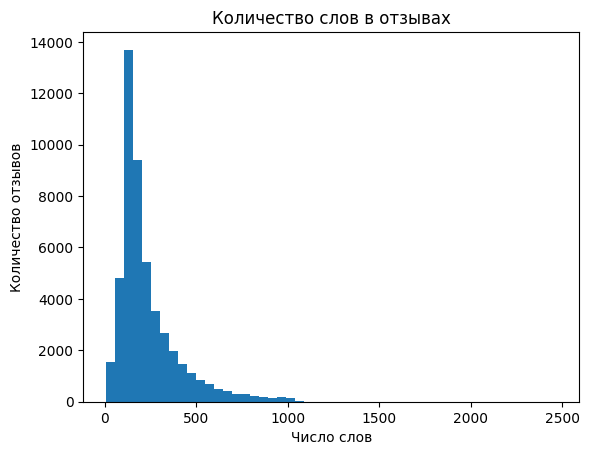

In [53]:
plt.hist(df['word_count'], bins=50)

plt.title('Количество слов в отзывах')
plt.xlabel('Число слов')
plt.ylabel('Количество отзывов')

plt.show()

Средняя длина отзывов по классам

In [55]:
df.groupby('sentiment')[['review_length', 'word_count']].describe()

review_length                                                \
                  count         mean          std   min    25%    50%   
sentiment                                                               
negative        24698.0  1294.739615   946.501793  32.0  706.0  974.0   
positive        24884.0  1326.278532  1032.597204  65.0  692.0  969.0   

                            word_count                                       \
               75%      max      count        mean         std   min    25%   
sentiment                                                                     
negative   1568.00   8969.0    24698.0  229.596607  165.103430   4.0  128.0   
positive   1615.25  13704.0    24884.0  233.090620  177.688169  10.0  125.0   

                                 
             50%    75%     max  
sentiment                        
negative   174.0  278.0  1522.0  
positive   172.0  284.0  2470.0

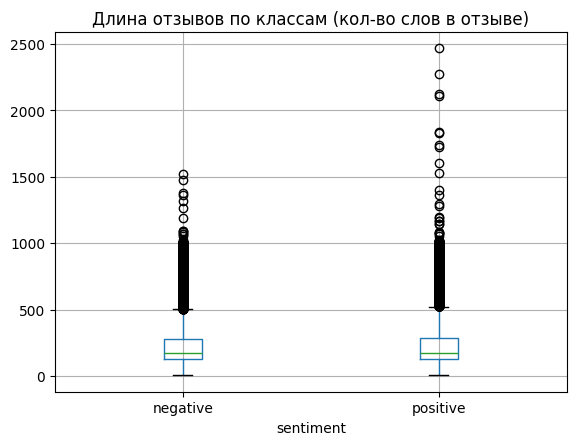

In [56]:
df.boxplot(column='word_count', by='sentiment')

plt.title('Длина отзывов по классам (кол-во слов в отзыве)')
plt.suptitle('')
plt.show()

Наблюдаем аналогичкую картинку примерно что и по длине, которую мы измеряли в количестве символов

Интересно посмотреть на корреляцию кол-ва слов в отзыве с кол-вом символов

In [57]:
df[['review_length', 'word_count']].corr()

,review_length,word_count
review_length,1.000000,0.996844
word_count,0.996844,1.000000


Очень сильная корреляция, практически прямая зависимость

Еще давайте посмотрим на корреляцию между длиной отзыва и его классом. Но для начало с помощью LabelEncoding переведем строковые классы в числовые

In [59]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])

df[['sentiment', 'sentiment_encoded']].head()

,sentiment,sentiment_encoded
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [60]:

df[['review_length', 'word_count', 'sentiment_encoded']].corr()

,review_length,word_count,sentiment_encoded
review_length,1.000000,0.996844,0.015917
word_count,0.996844,1.000000,0.010184
sentiment_encoded,0.015917,0.010184,1.000000


Очень маленькая корреляция между длиной отзыва и его классом. Соответственно завязывать на этих инсайтах наши будущие модели нельзя

# Итоговые выводы по EDA

1. Кол-во позитивных отзывов и негативных равно, классы сбалансированы
2. Есть прямая линейная зависимость между кол-вом символов и кол-вом слов в отзыве
3. Нет корреляции между длиной отзывов и его классом